In [1]:
import os
import warnings

import duckdb
import folium
import geopandas as gpd
import h3
import pandas as pd
from shapely.geometry import Polygon

warnings.filterwarnings("ignore")


In [2]:

path = r"C:\Users\bhavy\Massachusetts Institute of Technology\Truck Parking Capstone - General\Truck Stop Finder 🚚⛽\\"
# path = r"C:\Users\samcl\Massachusetts Institute of Technology\Truck Parking Capstone - Truck Stop Finder 🚚⛽\\"

In [3]:
sensor_loc = pd.read_csv(path + r"5. Source & Refrence Files\sensor_loc_w_ZIP5.csv",
                         dtype={"station_id": 'str', 'ZIP5': 'str'})
state_map = pd.read_csv(path + r"5. Source & Refrence Files\State_mapping.csv")
model_stop = pd.read_excel("output_excel/Model_Stops_V3.xlsx")
traffic_df = pd.read_csv(path + r"4. Working Data Files\Traffic Files\Capstone_truck\merged_filtered_modified.csv")


In [4]:
sensor_loc = sensor_loc[sensor_loc["State"] != "AK"].copy()

In [5]:

resolution = 4


def hr_p(row):
    return h3.latlng_to_cell(row["Latitude"], row["Longitude"], resolution)


sensor_loc["polygon"] = sensor_loc.apply(hr_p, axis=1)


In [6]:
sensor_loc

,Latitude,Longitude,Functional Class,State,Station Id,ZIP5,polygon
0,36.719788,-104.535744,4R,NM,WHIT01,87740,84268b3ffffffff
1,40.485651,-74.426438,3U,NJ,W41024,08901,842a107ffffffff
2,40.892000,-74.223000,3U,NJ,W21035,07512,842a105ffffffff
3,39.771974,-74.901328,3U,NJ,W07140,08009,842a137ffffffff
4,39.944480,-74.095954,3U,NJ,W06108,08751,842a13bffffffff
...,...,...,...,...,...,...,...
7930,34.710839,-76.736897,4U,NC,0A1501,28557,842ad51ffffffff
7931,35.551341,-82.731234,1U,NC,0A1003,28715,8444d99ffffffff
7932,33.937646,-78.555950,7U,NC,0A0901,28467,842ad39ffffffff
7933,35.946988,-82.004388,3R,NC,0A0501,28777,8444d95ffffffff


In [7]:
sensor_loc.drop(columns="ZIP5", inplace=True)

In [8]:
sensor_loc.columns

Index(['Latitude', 'Longitude', 'Functional Class', 'State', 'Station Id',
       'polygon'],
      dtype='object')

In [9]:
# folder = path + r"5. Source & Refrence Files\2024_traffic_data"
# out_dir = os.path.join(path, r"5. Source & Refrence Files\2024_traffic_parquet")
# os.makedirs(out_dir, exist_ok=True)
#
# # build mapping dict ONCE from your state_map df
# state_dict = state_map.set_index("state_code")["State"].to_dict()
#
# id_var_col = [
#     'record_type', 'state_code', 'f_system', 'station_id', 'travel_dir',
#     'travel_lane', 'year_record', 'month_record', 'day_record',
#     'day_of_week', 'restrictions'
# ]
#
# part = 0
#
# for filename in os.listdir(folder):
#     file_path = os.path.join(folder, filename)
#
#     if not filename.lower().endswith(".zip"):
#         continue
#
#     print(f"Opening ZIP: {filename}")
#
#     with zipfile.ZipFile(file_path, 'r') as z:
#         for inner_name in z.namelist():
#             if inner_name.endswith("/"):
#                 continue
#
#             print(f"  Processing inside ZIP: {inner_name}")
#
#             with z.open(inner_name) as f:
#                 # Read CSV from inside the ZIP
#                 df = pd.read_csv(
#                     f,
#                     delimiter="|",
#                     low_memory=False  # avoids dtype warning at cost of some RAM, OK for chunk
#                     # You can also pass dtype={} here if you know them
#                 )
#
#                 # Melt wide hours columns into long format
#                 df = pd.melt(
#                     df,
#                     id_vars=id_var_col,
#                     var_name="hours",
#                     value_name="traffic"
#                 )
#
#                 # Add state_name via map instead of big merge later
#                 df["State"] = df["state_code"].map(state_dict)
#                 df["station_id"] = df["station_id"].astype(str)
#
#                 # Save this chunk to Parquet and drop from memory
#                 out_path = os.path.join(out_dir, f"traffic_part_{part}.parquet")
#                 df.to_parquet(out_path, index=False)
#                 # print(f"    → wrote {out_path}")
#
#                 del df
#                 part += 1
#
# print(f"Done. Wrote {part} parquet files to {out_dir}")


In [10]:
out_dir = os.path.join(path, r"5. Source & Refrence Files\2024_traffic_parquet")
traffic_parquet_glob = f"{out_dir}/traffic_part_*.parquet"

In [11]:
con = duckdb.connect()
con.register("sensor_loc", sensor_loc)

In [12]:
out_dir = os.path.join(path, r"5. Source & Refrence Files\2024_traffic_parquet")
traffic_parquet_glob = f"{out_dir}/traffic_part_*.parquet"

In [13]:
con.execute(f"""
    CREATE OR REPLACE TABLE traffic_matched AS
    SELECT
        t.*,                           -- all columns from traffic
        s.*
    FROM read_parquet('{traffic_parquet_glob}') AS t
    LEFT JOIN sensor_loc AS s
      ON t.station_id = s."Station Id"
     AND t.State      = s.State
    WHERE s."Latitude" IS NOT NULL
""")


In [14]:
con.execute(f"""
    CREATE OR REPLACE TABLE traffic_unmatched  AS
    SELECT
        t.*,                           -- all columns from traffic
        s.*
    FROM read_parquet('{traffic_parquet_glob}') AS t
    LEFT JOIN sensor_loc AS s
      ON t.station_id = s."Station Id"
     AND t.State      = s.State
    WHERE s."Latitude" IS NULL
""")


In [15]:
con.execute("""
            UPDATE traffic_unmatched
            SET station_id = ltrim(station_id, '0')
            """)


In [16]:
# con.execute("""select *
#                from sensor_loc limit 5""").df()

In [17]:
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN Latitude')
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN Longitude')
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN "Functional Class"')
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN State_1')
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN "Station Id"')


In [18]:
con.execute("""select *
               from traffic_unmatched limit 5""").df()

,record_type,state_code,f_system,station_id,travel_dir,travel_lane,year_record,month_record,day_record,day_of_week,restrictions,hours,traffic,State,polygon
0,V,15,3U,2,1,1,2024,12,1,1,NaN,hour_00,48,HI,None
1,V,15,3U,2,1,1,2024,12,2,2,NaN,hour_00,35,HI,None
2,V,15,3U,2,1,1,2024,12,3,3,NaN,hour_00,23,HI,None
3,V,15,3U,2,1,1,2024,12,4,4,NaN,hour_00,26,HI,None
4,V,15,3U,2,1,1,2024,12,5,5,NaN,hour_00,30,HI,None


In [19]:
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN polygon')

In [20]:
con.execute("""
            INSERT INTO traffic_matched
            SELECT t.*,
                   s.*
            FROM traffic_unmatched t
                     LEFT JOIN sensor_loc s
                               ON t.station_id = s."Station Id"
                                   AND t.State = s.State
            WHERE s."Latitude" IS NOT NULL
            """)


In [21]:
# con.execute("""
#             CREATE OR REPLACE TABLE traffic_unmatched  AS
#             SELECT t.*,
#                    s.*
#             FROM traffic_unmatched t
#                      LEFT JOIN sensor_loc s
#                                ON t.station_id = s."Station Id"
#                                    AND t.State = s.State
#             WHERE s."Latitude" IS NULL
#             """)

In [22]:
con.execute("""CREATE OR REPLACE TABLE traffic_gp_matched  AS
            select record_type,state_code,f_system,station_id,travel_dir,year_record,month_record,day_record,day_of_week,restrictions,hours, sum(traffic) as "traffic_volume",State,Latitude,Longitude,"Functional Class",State_1,"Station Id",polygon, count(distinct travel_lane) as "lane_count"
               from traffic_matched
               group by record_type,state_code,f_system,station_id,travel_dir,year_record,month_record,day_record,day_of_week,restrictions,hours,State,Latitude,Longitude,"Functional Class",State_1,"Station Id",polygon
            """)



In [23]:
con.execute("""select count(station_id)
               from traffic_gp_matched""").df()

,count(station_id)
0,102180672


In [24]:
con.execute("""select count(*)
               from traffic_gp_matched""").df()

,count_star()
0,102180672


In [25]:
df = con.execute("""select State_1,
                           polygon,
                           travel_dir,
                           day_of_week,
                           hours,
                           lane_count,
                           avg(traffic_volume)                          as avg_traffic,
                           median(traffic_volume),
                           stddev(traffic_volume),
                           stddev(traffic_volume) / avg(traffic_volume) as CV
                    from traffic_gp_matched
                    group by State_1, polygon, travel_dir, day_of_week, hours, lane_count""").df()

In [26]:
df.to_csv(f"H3_{resolution}_agg_data.csv", index=False)

In [27]:
df['delta'] = abs((df["avg_traffic"] - df["median(traffic_volume)"]) / df["avg_traffic"])
df

,State_1,polygon,travel_dir,day_of_week,hours,lane_count,avg_traffic,median(traffic_volume),stddev(traffic_volume),CV,delta
0,IN,84266c1ffffffff,1,2,hour_20,2,682.195652,675.0,92.219453,0.135180,0.010548
1,MI,8427495ffffffff,7,2,hour_01,1,6.415094,6.0,4.538019,0.707397,0.064706
2,MI,8427419ffffffff,3,6,hour_02,1,20.326923,20.0,5.454702,0.268349,0.016083
3,NM,8448d0dffffffff,5,4,hour_20,2,79.942308,80.0,12.861881,0.160890,0.000722
4,NM,84268b3ffffffff,1,3,hour_20,1,6.760000,5.0,6.149697,0.909719,0.260355
...,...,...,...,...,...,...,...,...,...,...,...
1545523,NV,8428a6dffffffff,3,7,hour_04,1,29.000000,29.0,NaN,NaN,0.000000
1545524,UT,8426969ffffffff,1,1,hour_01,1,18.000000,18.0,NaN,NaN,0.000000
1545525,NV,842986bffffffff,1,5,hour_11,7,3238.000000,3238.0,NaN,NaN,0.000000
1545526,OH,842ab17ffffffff,3,1,hour_12,1,174.000000,174.0,NaN,NaN,0.000000


In [28]:
import matplotlib.pyplot as plt

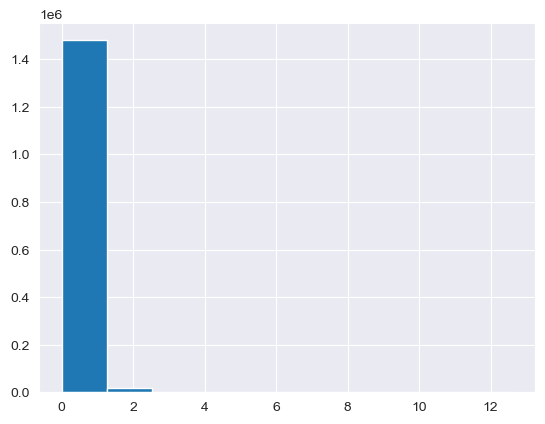

In [29]:
plt.hist(df["CV"])

plt.show()

In [30]:
df['delta'].describe()

count    1.544066e+06
mean     7.214251e-02
std      1.292123e-01
min      0.000000e+00
25%      1.038002e-02
50%      2.713510e-02
75%      7.018683e-02
max      1.000000e+00
Name: delta, dtype: float64

In [31]:
df['avg_traffic'].describe()

count    1.545528e+06
mean     5.971454e+02
std      1.024717e+03
min      0.000000e+00
25%      5.217308e+01
50%      2.000481e+02
75%      6.567500e+02
max      1.484850e+04
Name: avg_traffic, dtype: float64

In [32]:
df['CV'].describe()

count    1.499561e+06
mean     3.265300e-01
std      2.958048e-01
min      0.000000e+00
25%      1.554195e-01
50%      2.352533e-01
75%      3.998299e-01
max      1.261556e+01
Name: CV, dtype: float64

In [33]:
df[df['delta'] == 1]

,State_1,polygon,travel_dir,day_of_week,hours,lane_count,avg_traffic,median(traffic_volume),stddev(traffic_volume),CV,delta
1317,TX,8426d11ffffffff,5,3,hour_02,1,0.891892,0.0,1.523588,1.708266,1.0
1389,MT,84279ddffffffff,3,5,hour_03,1,0.127660,0.0,0.337318,2.642326,1.0
1399,OR,8428aa3ffffffff,5,7,hour_04,1,0.392157,0.0,0.896179,2.285257,1.0
1776,NE,84261c7ffffffff,1,4,hour_04,1,0.187500,0.0,0.490603,2.616550,1.0
2083,NE,84261d3ffffffff,7,1,hour_03,1,0.326531,0.0,0.591177,1.810478,1.0
...,...,...,...,...,...,...,...,...,...,...,...
1544234,ID,8426b25ffffffff,5,3,hour_01,1,0.562500,0.0,0.800705,1.423476,1.0
1544317,MN,84262e7ffffffff,3,1,hour_06,1,2.600000,0.0,4.774935,1.836513,1.0
1544619,ND,84278dbffffffff,7,1,hour_22,1,0.400000,0.0,0.547723,1.369306,1.0
1544751,MN,84262e7ffffffff,7,5,hour_02,1,0.600000,0.0,1.341641,2.236068,1.0


In [34]:
# Get the ZIP5 in truck data
# Check which ZIP5 in truck doesn't exist in sensor file
# If doesn't exist, either find the nearest one, or take ZIP3

In [35]:
def hr_p_model(row):
    return h3.latlng_to_cell(row["lat"], row["lng"], resolution)


model_stop["polygon"] = model_stop.apply(hr_p_model, axis=1)


In [36]:
model_stop[~model_stop["polygon"].isin(sensor_loc["polygon"].unique())]

,pin id,pinname,lat,lng,truckParkingSpotCount,f_system,link_id,review_score,amenities_score,overnightParking,polygon
27,33d29f1cb1f0f1eed32b8a5bb4c58f58,Freedom Fuels Truck Stop,32.842651,-85.774648,7,3,AL0000380000_80.54099999999998_80.641,NaN,NaN,0.0,8444ee3ffffffff
30,35d02fef7d9a24e237057162abab82b7,SuperMart #355,32.958932,-87.171788,10,3,AL0000250000_92.063_92.163,NaN,NaN,1.0,8444ed5ffffffff
31,378fb9f589cf7930275f25e4b5afbddd,Cocos #3 - EXXON,31.778154,-88.328553,5,3,AL0000170000_42.951_42.998,NaN,NaN,1.0,844453bffffffff
42,438124b4c06f3a5caffab2c07863b617,Inland,31.423438,-85.616458,35,3,AL0000530000_40.718_40.818,NaN,NaN,1.0,8444e17ffffffff
47,46c07d6c95484707dd4ad9a9ace967c0,Marathon Gas,31.504496,-86.922293,10,1,IN0000650000_100.727_100.824,NaN,NaN,1.0,8444ec9ffffffff
...,...,...,...,...,...,...,...,...,...,...,...
759,deafcfb9f6c5514a79bea1c363261eda,Big Boss 76,30.711069,-85.933857,12,1,52002000_1.538_1.574,NaN,NaN,1.0,8444e57ffffffff
762,e32c3cf73af2955e8103ca2bb44ca0a4,Love's Travel Stop # 674,27.872741,-81.593018,83,3,16170000_17.0_17.1,NaN,NaN,1.0,8444ad7ffffffff
770,eccd2a86bae4728b38627162ba297828,Navarre Walmart Supercenter Store #3439,30.412201,-86.830498,2,3,58030000_22.1_22.2,NaN,NaN,0.0,8444567ffffffff
775,f06d497659096949ed7c01894ba38694,Recreation park SB,26.145670,-80.578347,25,1,86075000_26.5_26.58,NaN,NaN,1.0,8444acdffffffff


In [41]:
graph = df.groupby(["polygon"]).agg({"avg_traffic": "sum"}).reset_index()

In [42]:
def h3_to_polygon(h):
    # H3 returns (lat, lng); shapely wants (lng, lat)
    boundary = h3.cell_to_boundary(h)
    return Polygon([(lng, lat) for lat, lng in boundary])


gdf = gpd.GeoDataFrame(
    graph,
    geometry=df["polygon"].apply(h3_to_polygon),
    crs="EPSG:4326"  # lat/lon
)

In [43]:
gdf

,polygon,avg_traffic,geometry
0,8412c91ffffffff,24305.158662,"POLYGON ((-85.77132 39.23587, -86.0549 39.1553..."
1,8412cb1ffffffff,17740.271092,"POLYGON ((-84.92933 42.23507, -85.23368 42.152..."
2,8412cb5ffffffff,68838.776288,"POLYGON ((-85.54828 45.15082, -85.87118 45.063..."
3,8412cbbffffffff,26235.945801,"POLYGON ((-103.67449 32.41279, -103.42978 32.5..."
4,8412d85ffffffff,34298.023590,"POLYGON ((-104.45482 36.49437, -104.20163 36.6..."
...,...,...,...
2356,845d115ffffffff,614274.311549,"POLYGON ((-121.20446 43.90943, -120.96665 44.0..."
2357,845d13dffffffff,57121.896257,"POLYGON ((-121.63031 41.7039, -121.39931 41.87..."
2358,845d145ffffffff,907292.394176,"POLYGON ((-80.93066 25.72672, -80.71751 25.829..."
2359,845d169ffffffff,242815.419915,"POLYGON ((-84.0469 30.21194, -83.81862 30.3148..."


In [44]:
m = folium.Map(location=[39.5, -98.35], zoom_start=4)

# Add choropleth
folium.Choropleth(
    geo_data=gdf.to_json(),
    data=gdf,
    columns=["polygon", "avg_traffic"],  # key + value
    key_on="feature.properties.polygon",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Average traffic"
).add_to(m)

m.save("traffic_hex_map.html")